In [17]:
!pip install nltk scikit-learn requests joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
import re
import requests
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import joblib


In [19]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rounak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)


In [36]:
fake = pd.read_csv("ISOT/Fake.csv")
true = pd.read_csv("ISOT/True.csv")

fake["label"] = 0   # Fake news
true["label"] = 1   # Real news


In [22]:
print(fake.duplicated().sum())
print(true.duplicated().sum())

3
206


In [23]:
fake = fake.drop_duplicates(subset=["text"])
fake = fake.reset_index(drop=True)

print("New shape:", fake.shape)

true = true.drop_duplicates(subset=["text"])
true = true.reset_index(drop=True)

print("New shape:", true.shape)

New shape: (17455, 5)
New shape: (21192, 5)


In [24]:
fake = fake[["text", "label"]]
true = true[["text", "label"]]


In [25]:
fake["text"] = fake["text"].apply(clean_text)
true["text"] = true["text"].apply(clean_text)


In [26]:
data = pd.concat([fake, true], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total samples:", data.shape)


Total samples: (38647, 2)


In [27]:
X = data["text"]
y = data["label"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer( max_features=1000, ngram_range=(1,1), max_df=0.7, min_df=5 )

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)



In [29]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report




In [30]:
print(fake.duplicated().sum())
print(true.duplicated().sum())
print(true['text'].nunique())
print(fake['text'].nunique())


10
270
20922
17445


In [31]:
X = data["text"]
y = data["label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC(max_iter=10000)

svm_model.fit(X_train_vec, y_train)

svm_pred = svm_model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


Accuracy: 0.992496765847348
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3468
           1       0.99      1.00      0.99      4262

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

# Train on vectorized data
nb_model.fit(X_train_vec, y_train)

# Predict on vectorized test data
nb_pred = nb_model.predict(X_test_vec)

nb_acc = accuracy_score(y_test, nb_pred)

print("MultinomialNB Accuracy:", round(nb_acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))


MultinomialNB Accuracy: 0.9386

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3468
           1       0.94      0.94      0.94      4262

    accuracy                           0.94      7730
   macro avg       0.94      0.94      0.94      7730
weighted avg       0.94      0.94      0.94      7730



In [33]:
pa_model = PassiveAggressiveClassifier(
    max_iter=1000,
    random_state=42
)

pa_model.fit(X_train_vec, y_train)

pa_pred = pa_model.predict(X_test_vec)

print("Passive Aggressive Accuracy:", accuracy_score(y_test, pa_pred))
print(classification_report(y_test, pa_pred))

Passive Aggressive Accuracy: 0.9912031047865459
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3468
           1       0.99      0.99      0.99      4262

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



Passive aggresive gave the best result

In [34]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# Get reports as dictionaries
svm_report = classification_report(y_test, svm_pred, output_dict=True)
nb_report = classification_report(y_test, nb_pred, output_dict=True)
pa_report = classification_report(y_test, pa_pred, output_dict=True)

# Extract weighted averages
svm_metrics = [
    svm_report['weighted avg']['recall'],
    svm_report['weighted avg']['precision'],
    svm_report['weighted avg']['f1-score']
]

nb_metrics = [
    nb_acc,
    nb_report['weighted avg']['recall'],
    nb_report['weighted avg']['precision'],
    nb_report['weighted avg']['f1-score']
]

pa_metrics = [
    pa_report['weighted avg']['recall'],
    pa_report['weighted avg']['precision'],
    pa_report['weighted avg']['f1-score']
]


In [35]:
models = ["Naive Bayes", "Passive Aggressive", "Linear SVM"]
metrics = ["Accuracy", "Recall", "Precision", "F1-score"]

data = np.array([nb_metrics, pa_metrics, svm_metrics])

x = np.arange(len(models))
width = 0.2

plt.figure()

for i in range(len(metrics)):
    plt.bar(x + i*width, data[:, i], width)

plt.xticks(x + width, models, rotation=30)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)

plt.legend(metrics)
plt.show()


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

Testing SVM model on LIAR DATASET

In [ ]:
import pandas as pd

In [ ]:
liar = pd.read_csv("LIAR/train.tsv", sep="\t", header=None)

# Column 2 = label
# Column 3 = statement text

liar = liar[[1,2]]
liar.columns = ["label", "text"]

real_labels = ["true", "mostly-true"]
fake_labels = ["false", "pants-fire"]

liar = liar[liar["label"].isin(real_labels + fake_labels)]

liar["label"] = liar["label"].apply(lambda x: 1 if x in real_labels else 0)

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [ ]:
liar["text"] = liar["text"].apply(clean_text)

In [ ]:
X_liar = tfidf.transform(liar["text"])

In [ ]:
liar_pred = svm_model.predict(X_liar)

print("LIAR Accuracy:", accuracy_score(liar["label"], liar_pred))
print(classification_report(liar["label"], liar_pred))

LIAR Accuracy: 0.44715698393077874
              precision    recall  f1-score   support

           0       0.44      0.96      0.60      2834
           1       0.61      0.05      0.09      3638

    accuracy                           0.45      6472
   macro avg       0.52      0.50      0.34      6472
weighted avg       0.53      0.45      0.31      6472



As we can see that SVM performs very bad on different datset 

Combine those 2 DATA SET together

In [ ]:
liar = pd.read_csv("LIAR/train.tsv", sep="\t", header=None)

# Column 1 = label
# Column 2 = statement text
liar = liar[[1,2]]
liar.columns = ["label", "text"]

print(liar["label"].value_counts())

label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


In [ ]:
fake_labels= ["pants-fire", "false", "barely-true"]
real_labels = ["half-true", "mostly-true", "true"]

liar = liar[liar["label"].isin(fake_labels + real_labels)]

liar["label"] = liar["label"].apply(
    lambda x: 0 if x in fake_labels else 1
)

print(liar["label"].value_counts())

label
1    5752
0    4488
Name: count, dtype: int64


In [ ]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

isot_df = pd.concat(
    [fake[["text","label"]],
     true[["text","label"]]],
    ignore_index=True
)

print(isot_df["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


combine those 2 datasets


In [ ]:
# ISOT fake = 0
fake["label"] = 0

# ISOT real = 1
true["label"] = 1

isot_df = pd.concat([fake[["text","label"]],
                     true[["text","label"]]],
                     ignore_index=True)

In [ ]:
combined_df = pd.concat([isot_df, liar], ignore_index=True)

combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(combined_df["label"].value_counts())

label
0    27969
1    27169
Name: count, dtype: int64


split the dataset

In [ ]:
from sklearn.model_selection import train_test_split

X = combined_df["text"]
y = combined_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

PA classifier

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report

tfidf = TfidfVectorizer(max_features=5000)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

model = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8918208197315923
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5594
           1       0.88      0.90      0.89      5434

    accuracy                           0.89     11028
   macro avg       0.89      0.89      0.89     11028
weighted avg       0.89      0.89      0.89     11028



SVM 

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)

svm_pred = svm_model.predict(X_test_vec)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9105005440696409
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      5594
           1       0.91      0.90      0.91      5434

    accuracy                           0.91     11028
   macro avg       0.91      0.91      0.91     11028
weighted avg       0.91      0.91      0.91     11028



MNB

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.8646173376858904
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      5594
           1       0.86      0.86      0.86      5434

    accuracy                           0.86     11028
   macro avg       0.86      0.86      0.86     11028
weighted avg       0.86      0.86      0.86     11028



### Compute All 3 Models

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
    "Passive Aggressive": {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="macro"),
        "Recall": recall_score(y_test, pred, average="macro"),
        "F1": f1_score(y_test, pred, average="macro"),
    },
    "Linear SVM": {
        "Accuracy": accuracy_score(y_test, svm_pred),
        "Precision": precision_score(y_test, svm_pred, average="macro"),
        "Recall": recall_score(y_test, svm_pred, average="macro"),
        "F1": f1_score(y_test, svm_pred, average="macro"),
    },
    "Naive Bayes": {
        "Accuracy": accuracy_score(y_test, nb_pred),
        "Precision": precision_score(y_test, nb_pred, average="macro"),
        "Recall": recall_score(y_test, nb_pred, average="macro"),
        "F1": f1_score(y_test, nb_pred, average="macro"),
    },
}

results_df = pd.DataFrame(results).T
print(results_df)

                    Accuracy  Precision    Recall        F1
Passive Aggressive  0.891821   0.891906  0.891963  0.891820
Linear SVM          0.910501   0.910556  0.910417  0.910468
Naive Bayes         0.864617   0.864601  0.864569  0.864583


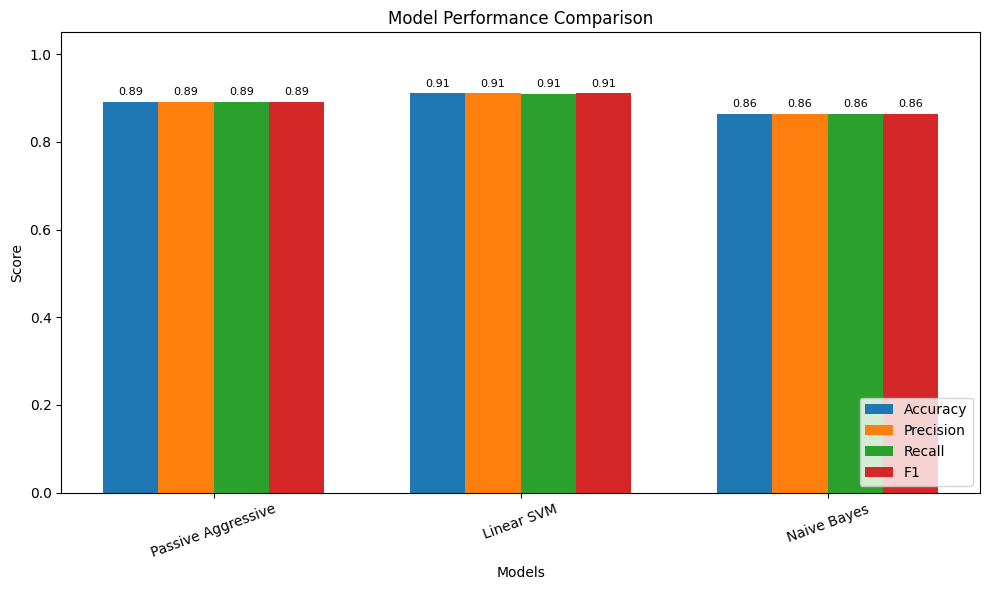

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]
models = results_df.index.tolist()

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(10,6))

for i, metric in enumerate(metrics):
    bars = plt.bar(x + i*width, results_df[metric], width, label=metric)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.01,
                 f"{height:.2f}",
                 ha='center',
                 va='bottom',
                 fontsize=8)

plt.xticks(x + width*1.5, models, rotation=20)
plt.ylim(0, 1.05)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()